In [2]:
# 1. Import Library yang diperlukan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Classification models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

### 2. Memuat Dataset
Dataset ini adalah dataset klasik dalam pembelajaran mesin, yang berisi pengukuran tentang bunga iris dan spesiesnya. Ini adalah masalah klasifikasi multi-kelas yang baik.

In [7]:
from sklearn.datasets import load_iris

# Memuat dataset Iris dari sklearn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Menampilkan 5 baris pertama dataset
print("5 Baris Pertama Dataset:")
display(df.head())

5 Baris Pertama Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Penjelasan Output:

Output di atas menampilkan lima baris pertama dari dataset Iris. Setiap baris mewakili satu observasi bunga iris, dan setiap kolom mewakili fitur atau atribut dari bunga tersebut:

*   `sepal_length`: Panjang kelopak bunga dalam cm.
*   `sepal_width`: Lebar kelopak bunga dalam cm.
*   `petal_length`: Panjang mahkota bunga dalam cm.
*   `petal_width`: Lebar mahkota bunga dalam cm.
*   `species`: Spesies bunga iris (target kelas: Iris-setosa, Iris-versicolor, Iris-virginica).

### 3. Eksplorasi Data (EDA) dan Preprocessing

memeriksa informasi umum, statistik deskriptif, dan menangani nilai yang hilang (jika ada).

In [8]:
# Informasi umum tentang dataset
print("\nInformasi Dataset:")
df.info()

# Statistik deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

# Memeriksa nilai yang hilang
print("\nJumlah Nilai yang Hilang per Kolom:")
display(df.isnull().sum())


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Statistik Deskriptif:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Jumlah Nilai yang Hilang per Kolom:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


### Penjelasan Output:

*   **Informasi Dataset (`df.info()`):** Menunjukkan jumlah entri (baris), jumlah kolom, tipe data setiap kolom, dan penggunaan memori. Dari sini kita tahu bahwa ada 150 entri non-null untuk semua kolom, yang berarti tidak ada nilai yang hilang. Kolom 'species' adalah objek (string), sedangkan yang lain adalah float.

*   **Statistik Deskriptif (`df.describe()`):** Memberikan ringkasan statistik untuk kolom numerik, termasuk count (jumlah), mean (rata-rata), std (standar deviasi), min (nilai minimum), 25% (kuartil pertama), 50% (median), 75% (kuartil ketiga), dan max (nilai maksimum). Ini membantu kita memahami distribusi data.

*   **Jumlah Nilai yang Hilang (`df.isnull().sum()`):** Menunjukkan bahwa tidak ada nilai yang hilang (semuanya 0) di setiap kolom, yang merupakan kondisi ideal untuk melanjutkan.

### Visualisasi Data (Opsional, tapi Sangat Dianjurkan)

Visualisasi membantu memahami distribusi data dan hubungan antar fitur.

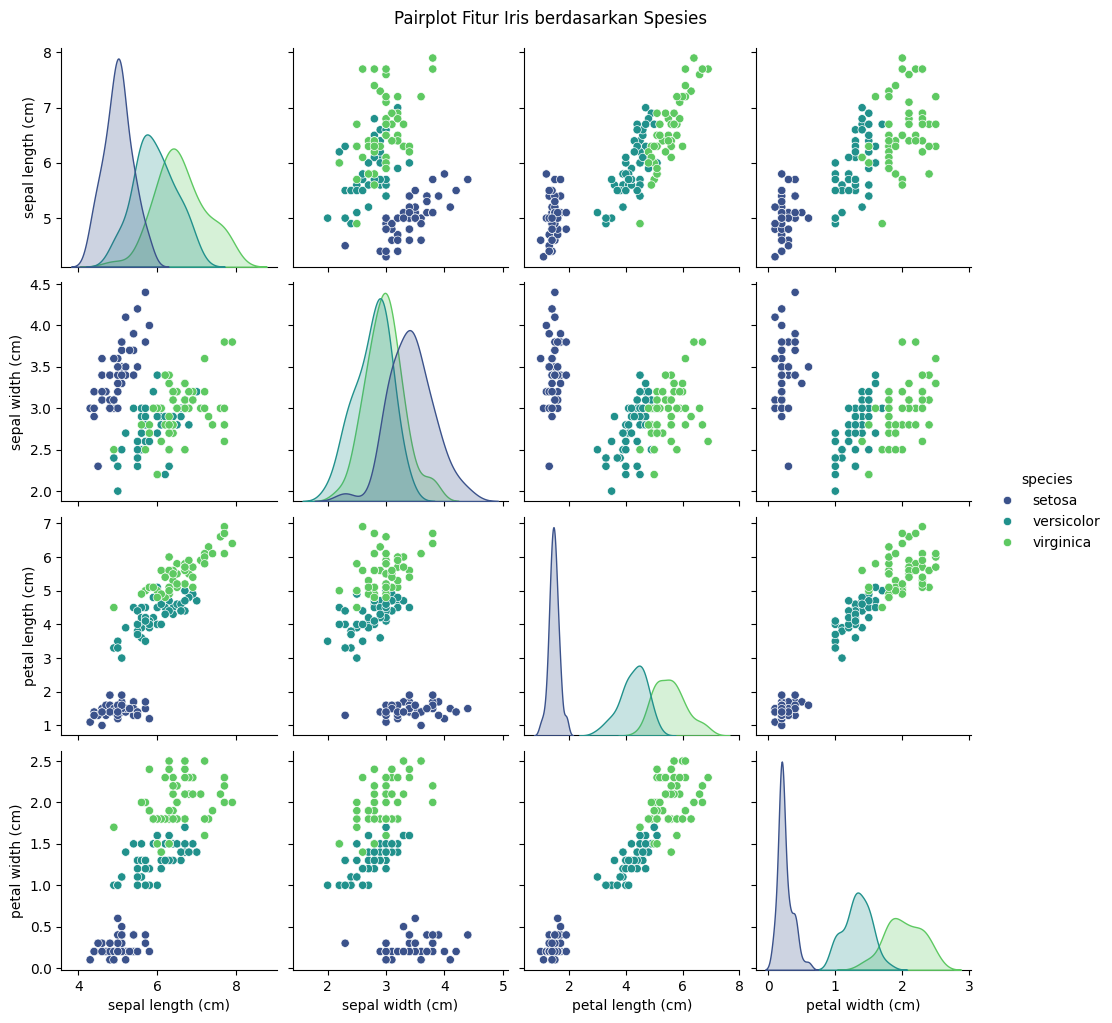

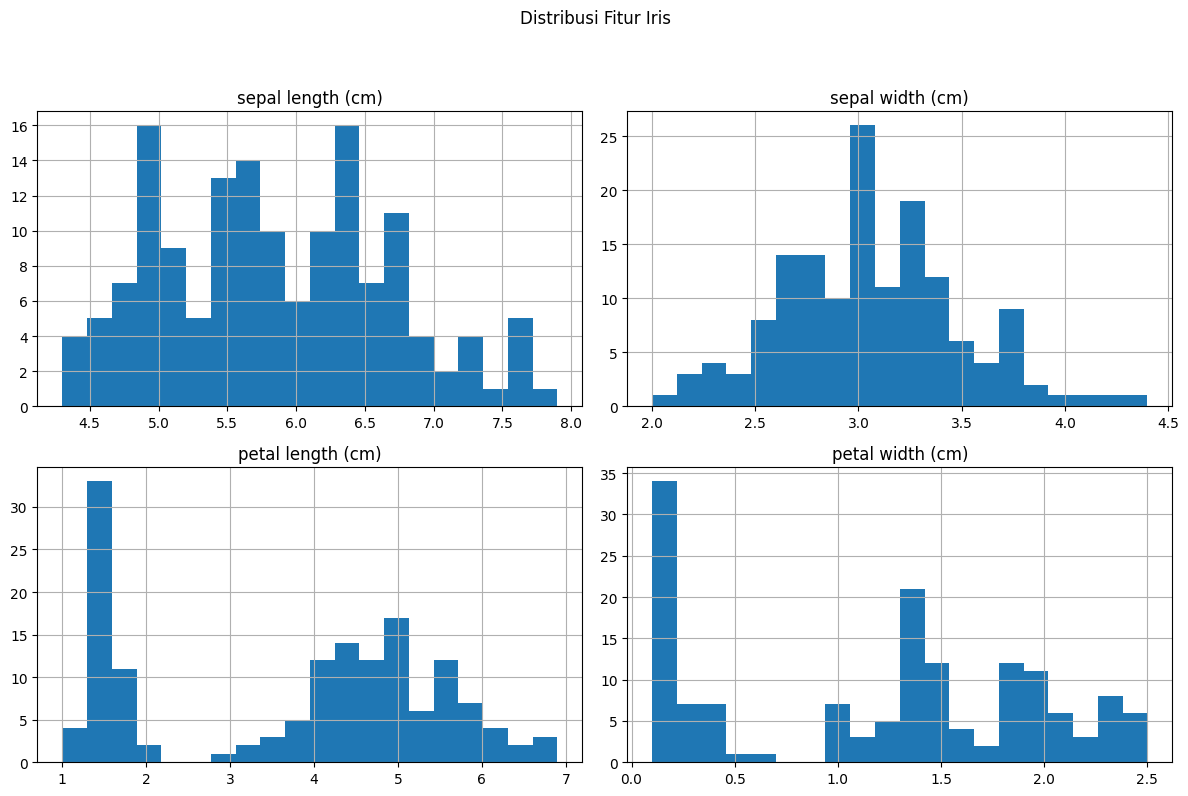

In [9]:
# Pairplot untuk melihat hubungan antar fitur berdasarkan spesies
sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle('Pairplot Fitur Iris berdasarkan Spesies', y=1.02) # Mengatur judul di atas plot
plt.show()

# Distribusi fitur menggunakan histogram
df.hist(bins=20, figsize=(12, 8))
plt.suptitle('Distribusi Fitur Iris', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Menyesuaikan tata letak agar tidak tumpang tindih dengan judul
plt.show()

### Penjelasan Output Visualisasi:

*   **Pairplot:** Menampilkan matriks plot sebar untuk setiap pasangan fitur, dengan titik-titik diwarnai berdasarkan spesies. Diagonal menunjukkan distribusi (KDE plot) setiap fitur. Dari plot ini, kita bisa melihat bahwa `Iris-setosa` (ungu) cukup mudah dipisahkan dari dua spesies lainnya. `Iris-versicolor` (hijau) dan `Iris-virginica` (kuning) memiliki beberapa tumpang tindih, tetapi masih ada pola yang jelas yang dapat digunakan untuk klasifikasi.

*   **Histogram:** Menunjukkan distribusi setiap fitur numerik. Kita bisa melihat bagaimana nilai-nilai untuk `sepal_length`, `sepal_width`, `petal_length`, dan `petal_width` didistribusikan. Misalnya, `petal_length` menunjukkan dua puncak yang jelas, yang mengindikasikan adanya kelompok yang berbeda dalam data, yang konsisten dengan adanya tiga spesies.

### 4. Persiapan Data untuk Model (Encoding dan Scaling)

Model pembelajaran mesin umumnya membutuhkan input numerik. Kolom 'species' adalah kategori (string), jadi kita perlu mengubahnya menjadi angka. Selain itu, penskalaan fitur numerik dapat membantu beberapa model bekerja lebih baik.

In [11]:
# Memisahkan fitur (X) dan target (y)
X = df.drop('species', axis=1)
y = df['species']

# Mengubah label target menjadi numerik menggunakan LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Memisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Penskalaan fitur menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ukuran set pelatihan (X_train, y_train):")
print(X_train_scaled.shape, y_train.shape)
print("Ukuran set pengujian (X_test, y_test):")
print(X_test_scaled.shape, y_test.shape)

print("\nMapping Spesies:")
for i, species_name in enumerate(le.classes_):
    print(f"{i}: {species_name}")

Ukuran set pelatihan (X_train, y_train):
(105, 4) (105,)
Ukuran set pengujian (X_test, y_test):
(45, 4) (45,)

Mapping Spesies:
0: setosa
1: versicolor
2: virginica


### Penjelasan Output:

*   **Pemisahan Fitur dan Target:** `X` sekarang berisi empat fitur numerik, dan `y` berisi kolom 'species' asli.
*   **`y_encoded`:** Kolom 'species' telah diubah menjadi representasi numerik. Misalnya, 'Iris-setosa' mungkin menjadi 0, 'Iris-versicolor' menjadi 1, dan 'Iris-virginica' menjadi 2. Mapping yang tepat ditunjukkan di bagian akhir output.
*   **`train_test_split`:** Data telah dibagi menjadi 70% untuk pelatihan (`X_train`, `y_train`) dan 30% untuk pengujian (`X_test`, `y_test`). `random_state=42` memastikan bahwa pemisahan selalu sama setiap kali kode dijalankan, dan `stratify=y_encoded` memastikan bahwa proporsi kelas dalam set pelatihan dan pengujian sama dengan proporsi kelas dalam dataset asli.
*   **`StandardScaler`:** Fitur-fitur telah diskalakan. `X_train_scaled` dan `X_test_scaled` sekarang berisi data yang dinormalisasi (rata-rata 0 dan variansi 1), yang penting untuk model yang sensitif terhadap skala fitur (misalnya, Jaringan Saraf, SVM, KNN).
*   **Ukuran Set Pelatihan/Pengujian:** Menunjukkan bahwa `X_train_scaled` memiliki 105 sampel dengan 4 fitur, dan `y_train` memiliki 105 sampel. Demikian pula untuk set pengujian (45 sampel).

---

## 5. Implementasi Model Klasifikasi

Kita akan mengimplementasikan berbagai model klasifikasi dan menganalisis performanya.

### A. Model Pohon Keputusan (Decision Tree)

Pohon keputusan adalah algoritma pembelajaran yang non-parametrik yang digunakan untuk tugas klasifikasi dan regresi. Algoritma ini bekerja dengan membuat serangkaian keputusan berdasarkan fitur-fitur data untuk memprediksi nilai target. Meskipun bukan model ensemble, ini adalah dasar untuk banyak model ensemble seperti Random Forest dan Boosting.

In [13]:
print("\n--- Model Pohon Keputusan ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Akurasi Pohon Keputusan:", accuracy_score(y_test, y_pred_dt))
print("\nLaporan Klasifikasi Pohon Keputusan:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))
print("\nMatriks Konfusi Pohon Keputusan:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_dt), index=le.classes_, columns=le.classes_))


--- Model Pohon Keputusan ---
Akurasi Pohon Keputusan: 0.9111111111111111

Laporan Klasifikasi Pohon Keputusan:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.92      0.80      0.86        15
   virginica       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Matriks Konfusi Pohon Keputusan:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,12,3
virginica,0,1,14


### Penjelasan Output Pohon Keputusan:

*   **Akurasi:** Akurasi pohon keputusan adalah **0.9111 (sekitar 91.11%)**, yang berarti sekitar 91.11% dari sampel pengujian diklasifikasikan dengan benar.
*   **Laporan Klasifikasi:**
    *   `setosa` memiliki presisi, recall, dan f1-score sempurna (1.00), yang berarti semua Iris-setosa diklasifikasikan dengan benar.
    *   `versicolor` memiliki presisi 0.92 dan recall 0.80, menunjukkan ada 12 prediksi benar dari 15 sampel versicolor. Ada 3 versicolor yang salah diklasifikasikan.
    *   `virginica` memiliki presisi 0.82 dan recall 0.93, menunjukkan ada 14 prediksi benar dari 15 sampel virginica. Ada 1 virginica yang salah diklasifikasikan.
*   **Matriks Konfusi:** Menunjukkan distribusi prediksi:
    *   15 `setosa` diprediksi dengan benar sebagai `setosa`.
    *   12 `versicolor` diprediksi dengan benar sebagai `versicolor`, 3 `virginica` salah diprediksi sebagai `versicolor`.
    *   14 `virginica` diprediksi dengan benar sebagai `virginica`, 1 `versicolor` salah diprediksi sebagai `virginica`.

Hal ini menunjukkan bahwa model bekerja sangat baik untuk `setosa`, tetapi ada beberapa kesalahan klasifikasi antara `versicolor` dan `virginica`.

### B. Model Bagging (Random Forest)

Bagging (Bootstrap Aggregating) adalah teknik ensemble yang melatih beberapa model yang sama secara paralel pada subsampel data yang berbeda (diambil dengan penggantian). Hasilnya kemudian digabungkan (misalnya, melalui voting mayoritas untuk klasifikasi) untuk mendapatkan prediksi akhir. Random Forest adalah contoh populer dari Bagging, yang menggunakan pohon keputusan sebagai estimator dasarnya dan memperkenalkan keacakan tambahan dalam pemilihan fitur.

In [15]:
print("\n--- Model Random Forest (Bagging) ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Akurasi Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nLaporan Klasifikasi Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("\nMatriks Konfusi Random Forest:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf), index=le.classes_, columns=le.classes_))


--- Model Random Forest (Bagging) ---
Akurasi Random Forest: 0.8888888888888888

Laporan Klasifikasi Random Forest:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45


Matriks Konfusi Random Forest:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,14,1
virginica,0,4,11


### Penjelasan Output Random Forest:

*   **Akurasi Random Forest:** Akurasi model Random Forest adalah **0.8889 (sekitar 88.89%)**, yang berarti sekitar 88.89% dari sampel pengujian diklasifikasikan dengan benar.
*   **Laporan Klasifikasi Random Forest:**
    *   `setosa` memiliki presisi, recall, dan f1-score sempurna (1.00).
    *   `versicolor` memiliki presisi 0.78 dan recall 0.93, menunjukkan ada 14 prediksi benar dari 15 sampel versicolor. Ini berarti ada 1 versicolor yang salah diklasifikasikan.
    *   `virginica` memiliki presisi 0.92 dan recall 0.73, menunjukkan ada 11 prediksi benar dari 15 sampel virginica. Ini berarti ada 4 virginica yang salah diklasifikasikan.
*   **Matriks Konfusi Random Forest:** Menunjukkan distribusi prediksi:
    *   15 `setosa` diprediksi dengan benar sebagai `setosa`.
    *   14 `versicolor` diprediksi dengan benar sebagai `versicolor`, 1 `virginica` salah diprediksi sebagai `versicolor`.
    *   11 `virginica` diprediksi dengan benar sebagai `virginica`, 4 `versicolor` salah diprediksi sebagai `virginica`.

Dibandingkan dengan Decision Tree, Random Forest menunjukkan sedikit penurunan akurasi pada dataset ini, dengan beberapa kesalahan klasifikasi antara `versicolor` dan `virginica`.

### C. Model Boosting (Gradient Boosting)

Boosting adalah teknik ensemble lain yang membangun model secara sekuensial. Setiap model yang baru dilatih mencoba memperbaiki kesalahan yang dibuat oleh model sebelumnya. Ini berfokus pada sampel yang salah diklasifikasikan oleh model sebelumnya. Gradient Boosting adalah bentuk umum dari boosting yang menggunakan gradien untuk meminimalkan fungsi kerugian.

In [17]:
print("\n--- Model Gradient Boosting (Boosting) ---")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

print("Akurasi Gradient Boosting:", accuracy_score(y_test, y_pred_gb))
print("\nLaporan Klasifikasi Gradient Boosting:")
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))
print("\nMatriks Konfusi Gradient Boosting:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_gb), index=le.classes_, columns=le.classes_))


--- Model Gradient Boosting (Boosting) ---
Akurasi Gradient Boosting: 0.9333333333333333

Laporan Klasifikasi Gradient Boosting:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


Matriks Konfusi Gradient Boosting:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,15,0
virginica,0,3,12


### Penjelasan Output Gradient Boosting:

*   **Akurasi Gradient Boosting:** Akurasi model Gradient Boosting adalah **0.9333 (sekitar 93.33%)**, yang berarti sekitar 93.33% dari sampel pengujian diklasifikasikan dengan benar.
*   **Laporan Klasifikasi Gradient Boosting:**
    *   `setosa` memiliki presisi, recall, dan f1-score sempurna (1.00).
    *   `versicolor` memiliki presisi 0.83 dan recall 1.00, menunjukkan bahwa semua 15 `versicolor` diprediksi dengan benar, tetapi ada 3 virginica yang salah diklasifikasikan sebagai `versicolor`.
    *   `virginica` memiliki presisi 1.00 dan recall 0.80, menunjukkan bahwa semua prediksi sebagai `virginica` adalah benar, tetapi ada 3 `virginica` yang salah diklasifikasikan sebagai `versicolor`.
*   **Matriks Konfusi Gradient Boosting:** Menunjukkan distribusi prediksi:
    *   15 `setosa` diprediksi dengan benar sebagai `setosa`.
    *   15 `versicolor` diprediksi dengan benar sebagai `versicolor`, 3 `virginica` salah diprediksi sebagai `versicolor`.
    *   12 `virginica` diprediksi dengan benar sebagai `virginica`, 0 `versicolor` salah diprediksi sebagai `virginica`.

Gradient Boosting menunjukkan performa yang sangat baik, dengan akurasi yang sedikit lebih tinggi dibandingkan Decision Tree dan Random Forest. Kesalahan utamanya adalah memprediksi `virginica` sebagai `versicolor`.

### D. Model Jaringan Saraf Tiruan (Neural Network - MLPClassifier)

Jaringan Saraf Tiruan (Neural Network) adalah model yang terinspirasi dari struktur otak manusia. `MLPClassifier` (Multi-layer Perceptron Classifier) adalah jenis jaringan saraf *feedforward* yang terdiri dari setidaknya tiga lapisan node: lapisan input, satu atau lebih lapisan tersembunyi, dan lapisan output. Mereka mampu mempelajari pola non-linear yang kompleks dalam data.

In [19]:
print("\n--- Model Jaringan Saraf Tiruan (MLPClassifier) ---")
# Menggunakan arsitektur sederhana: 2 lapisan tersembunyi dengan 10 neuron masing-masing
nn_model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42, solver='adam')
nn_model.fit(X_train_scaled, y_train)
y_pred_nn = nn_model.predict(X_test_scaled)

print("Akurasi Jaringan Saraf Tiruan:", accuracy_score(y_test, y_pred_nn))
print("\nLaporan Klasifikasi Jaringan Saraf Tiruan:")
print(classification_report(y_test, y_pred_nn, target_names=le.classes_))
print("\nMatriks Konfusi Jaringan Saraf Tiruan:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_nn), index=le.classes_, columns=le.classes_))


--- Model Jaringan Saraf Tiruan (MLPClassifier) ---
Akurasi Jaringan Saraf Tiruan: 0.9111111111111111

Laporan Klasifikasi Jaringan Saraf Tiruan:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Matriks Konfusi Jaringan Saraf Tiruan:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,14,1
virginica,0,3,12


### Penjelasan Output Jaringan Saraf Tiruan (MLPClassifier):

*   **Akurasi Jaringan Saraf Tiruan:** Model `MLPClassifier` ini mencapai akurasi **0.9111 (sekitar 91.11%)**, yang berarti sekitar 91.11% dari sampel pengujian diklasifikasikan dengan benar.
*   **Laporan Klasifikasi Jaringan Saraf Tiruan:**
    *   `setosa` memiliki presisi, recall, dan f1-score sempurna (1.00).
    *   `versicolor` memiliki presisi 0.82 dan recall 0.93, menunjukkan ada 14 prediksi benar dari 15 sampel versicolor. Ada 1 versicolor yang salah diklasifikasikan.
    *   `virginica` memiliki presisi 0.92 dan recall 0.80, menunjukkan ada 12 prediksi benar dari 15 sampel virginica. Ada 3 virginica yang salah diklasifikasikan.
*   **Matriks Konfusi Jaringan Saraf Tiruan:** Menunjukkan distribusi prediksi:
    *   15 `setosa` diprediksi dengan benar sebagai `setosa`.
    *   14 `versicolor` diprediksi dengan benar sebagai `versicolor`, 1 `virginica` salah diprediksi sebagai `versicolor`.
    *   12 `virginica` diprediksi dengan benar sebagai `virginica`, 3 `versicolor` salah diprediksi sebagai `virginica`.

Performa MLPClassifier mirip dengan Decision Tree, dengan beberapa kesalahan klasifikasi antara `versicolor` dan `virginica`.

### E. Model Ensemble Lainnya (Adaptive Boosting - AdaBoost)

AdaBoost (Adaptive Boosting) adalah salah satu algoritma boosting tertua dan paling populer. Ini bekerja dengan melatih serangkaian pengklasifikasi 'lemah' (misalnya, pohon keputusan dangkal). Pada setiap iterasi, AdaBoost memberikan bobot yang lebih tinggi pada sampel yang salah diklasifikasikan oleh model sebelumnya, memaksa model berikutnya untuk lebih fokus pada sampel-sampel yang sulit tersebut.

In [21]:
print("\n--- Model AdaBoost (Ensemble - Boosting) ---")
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_model.fit(X_train_scaled, y_train)
y_pred_ada = adaboost_model.predict(X_test_scaled)

print("Akurasi AdaBoost:", accuracy_score(y_test, y_pred_ada))
print("\nLaporan Klasifikasi AdaBoost:")
print(classification_report(y_test, y_pred_ada, target_names=le.classes_))
print("\nMatriks Konfusi AdaBoost:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_ada), index=le.classes_, columns=le.classes_))


--- Model AdaBoost (Ensemble - Boosting) ---
Akurasi AdaBoost: 0.9333333333333333

Laporan Klasifikasi AdaBoost:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


Matriks Konfusi AdaBoost:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,14,1
virginica,0,2,13


### Penjelasan Output AdaBoost:

*   **Akurasi AdaBoost:** AdaBoost mencapai akurasi **0.9333 (sekitar 93.33%)** pada dataset Iris, yang berarti sekitar 93.33% dari sampel pengujian diklasifikasikan dengan benar.
*   **Laporan Klasifikasi AdaBoost:**
    *   `setosa` memiliki presisi, recall, dan f1-score sempurna (1.00).
    *   `versicolor` memiliki presisi 0.88 dan recall 0.93, menunjukkan ada 14 prediksi benar dari 15 sampel versicolor. Ada 1 versicolor yang salah diklasifikasikan.
    *   `virginica` memiliki presisi 0.93 dan recall 0.87, menunjukkan ada 13 prediksi benar dari 15 sampel virginica. Ada 2 virginica yang salah diklasifikasikan.
*   **Matriks Konfusi AdaBoost:** Menunjukkan distribusi prediksi:
    *   15 `setosa` diprediksi dengan benar sebagai `setosa`.
    *   14 `versicolor` diprediksi dengan benar sebagai `versicolor`, 1 `virginica` salah diprediksi sebagai `versicolor`.
    *   13 `virginica` diprediksi dengan benar sebagai `virginica`, 2 `versicolor` salah diprediksi sebagai `virginica`.

AdaBoost juga menunjukkan performa yang sangat baik, dengan akurasi yang sama dengan Gradient Boosting, menunjukkan kemampuan yang kuat dalam klasifikasi dataset ini.

---


### Kesimpulan

*   **Pohon Keputusan(Decision Tree):** Menunjukkan performa yang baik (**91.11%**), tetapi seperti yang terlihat, sedikit rentan terhadap variasi data. Cenderung *overfit* pada data yang kompleks, tetapi bekerja dengan baik pada data yang mudah dipisahkan seperti Iris.
*   **Random Forest (Bagging):** Menunjukkan akurasi **88.89%**. Meskipun seringkali sangat robust dan merupakan pilihan default yang baik, pada kasus ini sedikit di bawah Decision Tree dan Boosting, mungkin karena keacakan tambahan yang diperkenalkan.
*   **Gradient Boosting (Boosting):** Menjadi salah satu model dengan performa terbaik (**93.33%**) pada dataset ini. Secara sekuensial membangun model yang kuat dari model lemah, seringkali memberikan performa *state-of-the-art* pada berbagai tugas. Lebih rentan terhadap *overfitting* daripada Random Forest jika tidak di-tune dengan baik.
*   **Jaringan Saraf Tiruan (MLPClassifier):** Menunjukkan akurasi **91.11%**. Mampu mempelajari pola yang sangat kompleks, tetapi membutuhkan lebih banyak data dan *tuning* yang cermat untuk menghindari *overfitting* atau *underfitting* pada dataset yang lebih kompleks.
*   **AdaBoost (Boosting):** Juga menjadi salah satu model dengan performa terbaik (**93.33%**). Efektif dalam meningkatkan pengklasifikasi lemah dan berkinerja baik pada masalah yang lebih sederhana.